#### Model Benchmarking — CreditRisk Analyser

**Objective:** Compare Logistic Regression (production baseline) against XGBoost and LightGBM on the same preprocessing pipeline and evaluation criteria.

**Evaluation priority:** Default Recall at threshold 0.40 — missing a defaulter costs the full principal (asymmetric loss), so recall is the primary metric, not accuracy.

**Pipeline:** Identical to `prediction_helper.py` — same cleaning, same 4 engineered features, same train/test split (`random_state=42`, `stratify=y`), same threshold.

| Stage | Detail |
|---|---|
| Dataset | `credit_risk_dataset.csv` — 32,581 records, 21.8% default rate |
| Split | 80/20, stratified, random_state=42 |
| Threshold | PD ≥ 0.40 (recall-optimised, asymmetric loss) |
| Tuning | Optuna — 60 trials per tree model |
| Explainability | SHAP TreeExplainer for tree models |

#### Setup

In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

THRESHOLD  = 0.40
SEED       = 42
N_TRIALS   = 60
TEST_SIZE  = 0.20

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('All packages loaded.')

All packages loaded.


#### Data Cleaning — Mirror Production Pipeline

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
print(f'Raw shape: {df.shape}  |  Default rate: {df.loan_status.mean():.1%}')

Raw shape: (32581, 12)  |  Default rate: 21.8%


In [3]:
# ── Outlier capping  ─────────────────────────────────────
df.loc[df['person_age'] > 80, 'person_age'] = 80
df.loc[df['person_emp_length'] > 40, 'person_emp_length'] = 40

# ── Missingness indicators BEFORE imputation ─────────────────────────────────
df['emp_length_missing'] = df['person_emp_length'].isna().astype(int)
df['int_rate_missing']   = df['loan_int_rate'].isna().astype(int)

# ── Median imputation ────────────────────────────────────────────────────────
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate']     = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print(f'Missing after imputation: {df.isnull().sum().sum()}')
print(df[['person_age', 'person_emp_length', 'emp_length_missing', 'int_rate_missing']].describe().T)

Missing after imputation: 0
                      count       mean       std   min   25%   50%   75%   max
person_age          32581.0  27.725515  6.233069  20.0  23.0  26.0  30.0  80.0
person_emp_length   32581.0   4.762868  3.990296   0.0   2.0   4.0   7.0  40.0
emp_length_missing  32581.0   0.027470  0.163451   0.0   0.0   0.0   0.0   1.0
int_rate_missing    32581.0   0.095639  0.294099   0.0   0.0   0.0   0.0   1.0


#### Feature Engineering — Mirror `prepare_features()` Exactly

In [4]:
# ── 4 engineered features (must match prediction_helper.prepare_features) ─────
df['loan_percent_income']  = df['loan_amnt'] / df['person_income']
df['income_to_loan_ratio'] = (df['person_income'] / df['loan_amnt']).clip(upper=50)
df['int_rate_x_loan_pct']  = df['loan_int_rate'] * df['loan_percent_income']
df['loan_per_cred_hist']   = df['loan_amnt'] / (df['cb_person_cred_hist_length'].clip(lower=1) + 1)
df['risk_score_proxy']     = (df['loan_int_rate'] * df['loan_percent_income']
                               / (df['person_income'] / 1e4).clip(lower=0.01))

print('Engineered feature correlations with default:')
eng_feats = ['int_rate_x_loan_pct', 'risk_score_proxy', 'income_to_loan_ratio',
             'loan_per_cred_hist', 'loan_percent_income']
print(df[eng_feats + ['loan_status']].corr()['loan_status'].drop('loan_status').round(3))

Engineered feature correlations with default:
int_rate_x_loan_pct     0.454
risk_score_proxy        0.442
income_to_loan_ratio   -0.198
loan_per_cred_hist      0.095
loan_percent_income     0.386
Name: loan_status, dtype: float64


In [5]:
# ── One-hot encode categorical columns ───────────────────────────────────────
df_encoded = pd.get_dummies(
    df.drop(columns=['loan_status']),
    columns=['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
)

# Load production column order and align
expected_columns = joblib.load('expected_columns.pkl')
df_encoded = df_encoded.reindex(columns=expected_columns, fill_value=0)

X = df_encoded
y = df['loan_status']

print(f'Feature matrix: {X.shape}  |  Expected columns: {len(expected_columns)}')
assert X.shape[1] == len(expected_columns), 'Column mismatch — check pipeline!'
print('Column alignment: OK')

Feature matrix: (32581, 28)  |  Expected columns: 28
Column alignment: OK


####  Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# Scaler only for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Class imbalance ratio for XGBoost scale_pos_weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train default rate: {y_train.mean():.1%}  |  Test default rate: {y_test.mean():.1%}')
print(f'scale_pos_weight (XGBoost): {scale_pos_weight:.2f}')

Train: (26064, 28)  |  Test: (6517, 28)
Train default rate: 21.8%  |  Test default rate: 21.8%
scale_pos_weight (XGBoost): 3.58


#### Helper — Evaluation at Custom Threshold

In [7]:
def evaluate(name, y_true, y_prob, threshold=THRESHOLD):
    """Full evaluation report at a given PD threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Model':     name,
        'AUC':       round(roc_auc_score(y_true, y_prob), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'FN (missed defaults)': int(fn),
        'FP (false alarms)':    int(fp),
        'TP (caught defaults)': int(tp),
    }

results = []

#### Model 1 — Logistic Regression (Production Baseline)

Exact replica of the production model: `class_weight='balanced'`, `C=0.1`, `max_iter=2000`, solver `lbfgs`.

In [8]:
t0 = time.perf_counter()
lr = LogisticRegression(
    class_weight='balanced', C=0.1, max_iter=2000, solver='lbfgs', random_state=SEED
)
lr.fit(X_train_scaled, y_train)
lr_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_infer_time = (time.perf_counter() - t0) / len(X_test) * 1000  # ms per record

lr_result = evaluate('Logistic Regression (baseline)', y_test, lr_probs)
lr_result['Train time (s)'] = round(lr_train_time, 2)
lr_result['Inference (ms/rec)'] = round(lr_infer_time, 4)
results.append(lr_result)

print(classification_report(y_test, (lr_probs >= THRESHOLD).astype(int)))
print(f"AUC: {lr_result['AUC']}  |  Recall: {lr_result['Recall']}  |  FN: {lr_result['FN (missed defaults)']}")

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      5095
           1       0.51      0.83      0.63      1422

    accuracy                           0.79      6517
   macro avg       0.72      0.80      0.74      6517
weighted avg       0.85      0.79      0.80      6517

AUC: 0.8811  |  Recall: 0.8263  |  FN: 247


#### 7. Model 2 — XGBoost (Optuna Tuned)

Tree models do **not** need StandardScaler — trained directly on raw features.
Class imbalance handled via `scale_pos_weight` (ratio of negatives to positives).

In [9]:
def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight':  scale_pos_weight,
        'eval_metric':       'auc',
        'use_label_encoder': False,
        'random_state':      SEED,
        'n_jobs':            -1,
    }
    # 3-fold CV on training data to avoid leakage
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    aucs = []
    for tr_idx, val_idx in cv.split(X_train, y_train):
        m = xgb.XGBClassifier(**params)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx], verbose=False)
        p = m.predict_proba(X_train.iloc[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_train.iloc[val_idx], p))
    return np.mean(aucs)

print(f'Running Optuna XGBoost search ({N_TRIALS} trials) ...')
xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest CV AUC: {xgb_study.best_value:.4f}')
print('Best params:', xgb_study.best_params)

Running Optuna XGBoost search (60 trials) ...


Best trial: 28. Best value: 0.942539: 100%|██████████| 60/60 [03:26<00:00,  3.44s/it]


Best CV AUC: 0.9425
Best params: {'n_estimators': 785, 'max_depth': 4, 'learning_rate': 0.07994394721362903, 'subsample': 0.9494391059264029, 'colsample_bytree': 0.8675732353675297, 'min_child_weight': 6, 'reg_alpha': 0.00010460364257215727, 'reg_lambda': 0.05575078871152798}


In [10]:
# Train final XGBoost on full training set with best params
best_xgb_params = dict(
    **xgb_study.best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1,
)

t0 = time.perf_counter()
xgb_model = xgb.XGBClassifier(**best_xgb_params)
xgb_model.fit(X_train, y_train, verbose=False)
xgb_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_infer_time = (time.perf_counter() - t0) / len(X_test) * 1000

xgb_result = evaluate('XGBoost (Optuna tuned)', y_test, xgb_probs)
xgb_result['Train time (s)'] = round(xgb_train_time, 2)
xgb_result['Inference (ms/rec)'] = round(xgb_infer_time, 4)
results.append(xgb_result)

print(classification_report(y_test, (xgb_probs >= THRESHOLD).astype(int)))
print(f"AUC: {xgb_result['AUC']}  |  Recall: {xgb_result['Recall']}  |  FN: {xgb_result['FN (missed defaults)']}")

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      5095
           1       0.72      0.84      0.78      1422

    accuracy                           0.89      6517
   macro avg       0.84      0.87      0.85      6517
weighted avg       0.90      0.89      0.90      6517

AUC: 0.9503  |  Recall: 0.8368  |  FN: 232


#### Model 3 — LightGBM (Optuna Tuned)

In [11]:
def lgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'class_weight':     'balanced',
        'random_state':     SEED,
        'n_jobs':           -1,
        'verbose':          -1,
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    aucs = []
    for tr_idx, val_idx in cv.split(X_train, y_train):
        m = lgb.LGBMClassifier(**params)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        p = m.predict_proba(X_train.iloc[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_train.iloc[val_idx], p))
    return np.mean(aucs)

print(f'Running Optuna LightGBM search ({N_TRIALS} trials) ...')
lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest CV AUC: {lgb_study.best_value:.4f}')
print('Best params:', lgb_study.best_params)

Running Optuna LightGBM search (60 trials) ...


Best trial: 31. Best value: 0.942986: 100%|██████████| 60/60 [02:05<00:00,  2.10s/it]


Best CV AUC: 0.9430
Best params: {'n_estimators': 480, 'max_depth': 6, 'learning_rate': 0.047779983278651086, 'num_leaves': 107, 'subsample': 0.9519182066800891, 'colsample_bytree': 0.6510585481147093, 'min_child_samples': 19, 'reg_alpha': 0.0001002366031872542, 'reg_lambda': 0.01717609421865106}


In [12]:
best_lgb_params = dict(
    **lgb_study.best_params,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

t0 = time.perf_counter()
lgb_model = lgb.LGBMClassifier(**best_lgb_params)
lgb_model.fit(X_train, y_train)
lgb_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
lgb_infer_time = (time.perf_counter() - t0) / len(X_test) * 1000

lgb_result = evaluate('LightGBM (Optuna tuned)', y_test, lgb_probs)
lgb_result['Train time (s)'] = round(lgb_train_time, 2)
lgb_result['Inference (ms/rec)'] = round(lgb_infer_time, 4)
results.append(lgb_result)

print(classification_report(y_test, (lgb_probs >= THRESHOLD).astype(int)))
print(f"AUC: {lgb_result['AUC']}  |  Recall: {lgb_result['Recall']}  |  FN: {lgb_result['FN (missed defaults)']}")

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      5095
           1       0.73      0.84      0.79      1422

    accuracy                           0.90      6517
   macro avg       0.84      0.88      0.86      6517
weighted avg       0.91      0.90      0.90      6517

AUC: 0.9505  |  Recall: 0.8439  |  FN: 222


#### Model Comparison

In [13]:
comparison_df = pd.DataFrame(results).set_index('Model')
display(comparison_df)

,AUC,Recall,Precision,F1,FN (missed defaults),FP (false alarms),TP (caught defaults),Train time (s),Inference (ms/rec)
Model,,,,,,,,,
Logistic Regression (baseline),0.8811,0.8263,0.5054,0.6272,247,1150,1175,0.16,0.0010
XGBoost (Optuna tuned),0.9503,0.8368,0.7230,0.7757,232,456,1190,1.21,0.0038
LightGBM (Optuna tuned),0.9505,0.8439,0.7344,0.7853,222,434,1200,0.76,0.0060


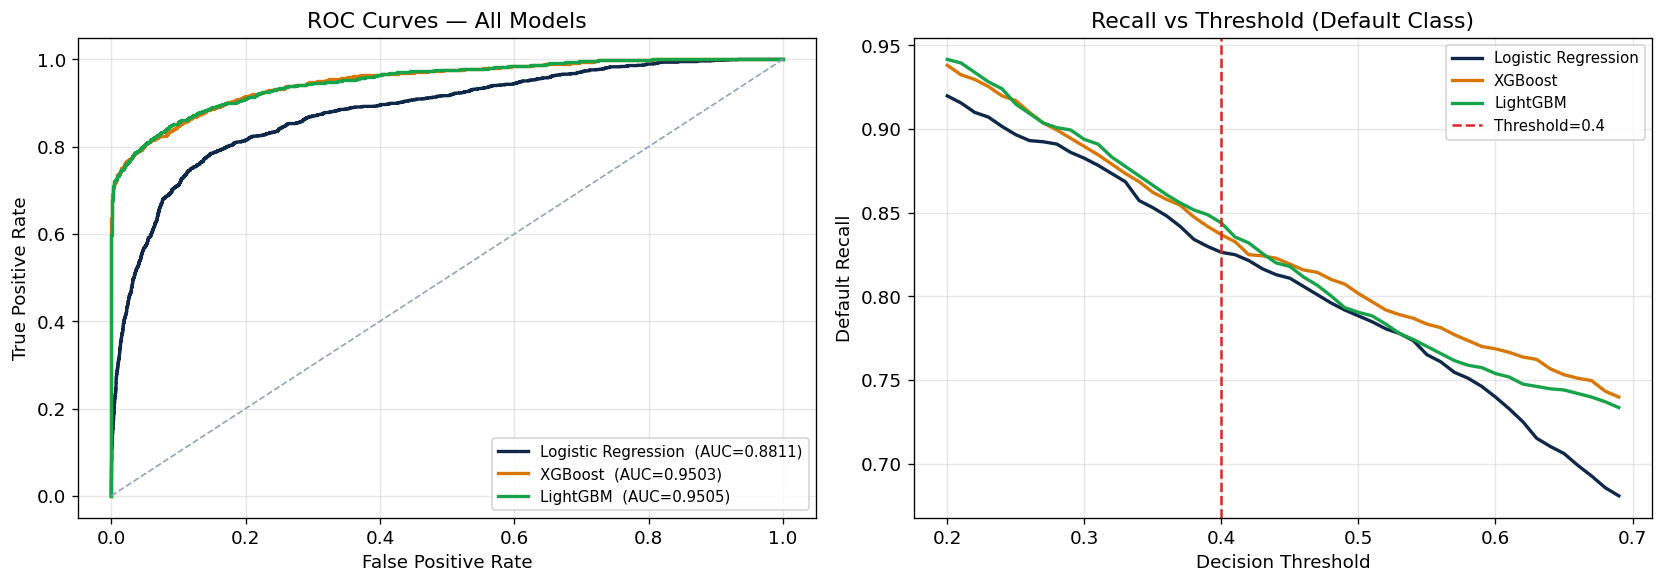

Saved: benchmark_roc_recall.png


In [14]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, probs, color in [
    ('Logistic Regression', lr_probs,  '#0F2748'),
    ('XGBoost',             xgb_probs, '#D97706'),
    ('LightGBM',            lgb_probs, '#16A34A'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f'{name}  (AUC={auc_val:.4f})')

axes[0].plot([0,1],[0,1],'--', color='#94A3B8', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# ── Recall vs Threshold ──────────────────────────────────────────────────────
thresholds_range = np.arange(0.20, 0.70, 0.01)
for name, probs, color in [
    ('Logistic Regression', lr_probs,  '#0F2748'),
    ('XGBoost',             xgb_probs, '#D97706'),
    ('LightGBM',            lgb_probs, '#16A34A'),
]:
    recalls = [recall_score(y_test, (probs >= t).astype(int)) for t in thresholds_range]
    axes[1].plot(thresholds_range, recalls, lw=2, color=color, label=name)

axes[1].axvline(THRESHOLD, color='#DC2626', linestyle='--', lw=1.5, label=f'Threshold={THRESHOLD}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Default Recall')
axes[1].set_title('Recall vs Threshold (Default Class)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_roc_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_roc_recall.png')

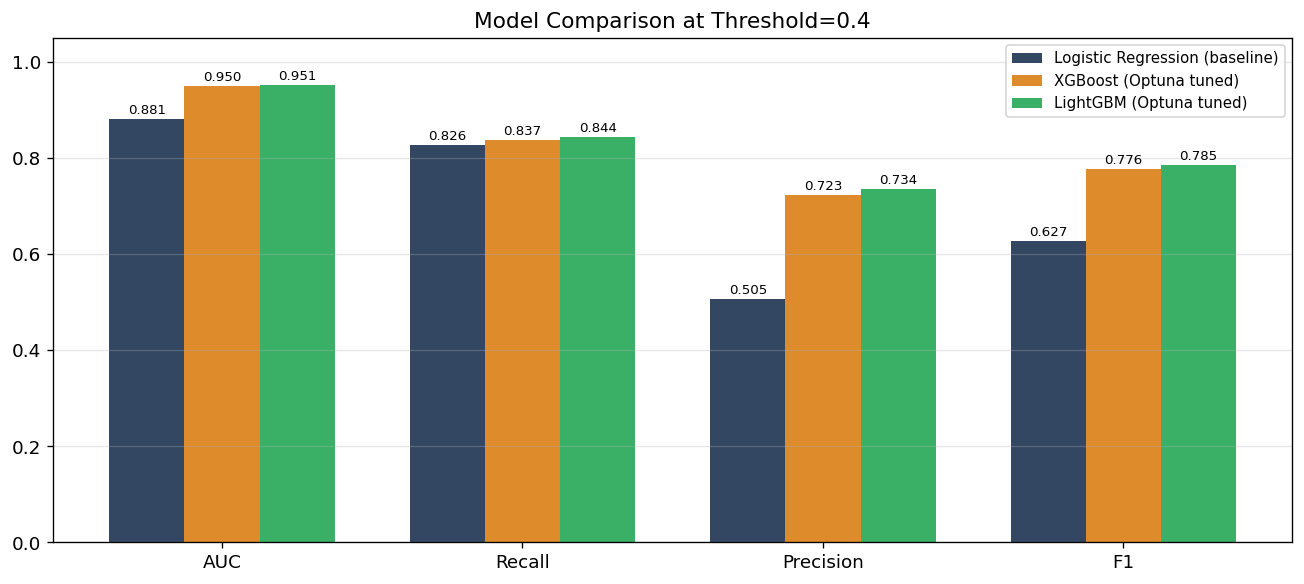

Saved: benchmark_metrics.png


In [15]:
# ── Comparison bar chart ─────────────────────────────────────────────────────
metrics = ['AUC', 'Recall', 'Precision', 'F1']
x      = np.arange(len(metrics))
width  = 0.25
colors = ['#0F2748', '#D97706', '#16A34A']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (row, color) in enumerate(zip(comparison_df.itertuples(), colors)):
    vals = [getattr(row, m) for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=row.Index, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title(f'Model Comparison at Threshold={THRESHOLD}', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('benchmark_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_metrics.png')

#### SHAP Analysis — Best Tree Model

SHAP (SHapley Additive exPlanations) gives exact feature attributions for tree models.
For logistic regression, `coefficient × scaled_value` is already exact — no approximation needed.

We run SHAP on the best tree model (whichever has higher AUC between XGBoost and LightGBM).

In [16]:
# Pick best tree model by AUC
if xgb_result['AUC'] >= lgb_result['AUC']:
    best_tree_model = xgb_model
    best_tree_name  = 'XGBoost'
    best_tree_probs = xgb_probs
else:
    best_tree_model = lgb_model
    best_tree_name  = 'LightGBM'
    best_tree_probs = lgb_probs

print(f'Running SHAP TreeExplainer on: {best_tree_name}')

explainer   = shap.TreeExplainer(best_tree_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values may be a list [class0, class1]
if isinstance(shap_values, list):
    sv = shap_values[1]  # class 1 = default
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')

Running SHAP TreeExplainer on: LightGBM
SHAP values shape: (6517, 28)


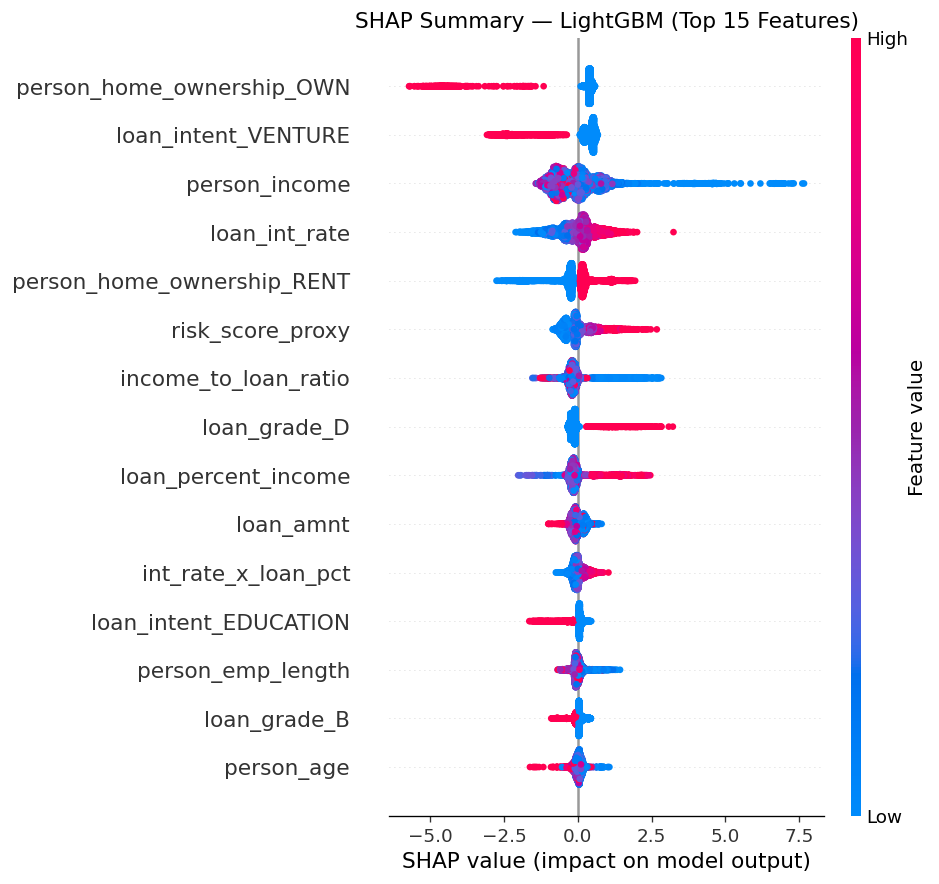

Saved: shap_summary.png


In [17]:
# ── Summary plot — global feature importance ─────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, feature_names=list(expected_columns),
                  max_display=15, show=False)
plt.title(f'SHAP Summary — {best_tree_name} (Top 15 Features)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_summary.png')

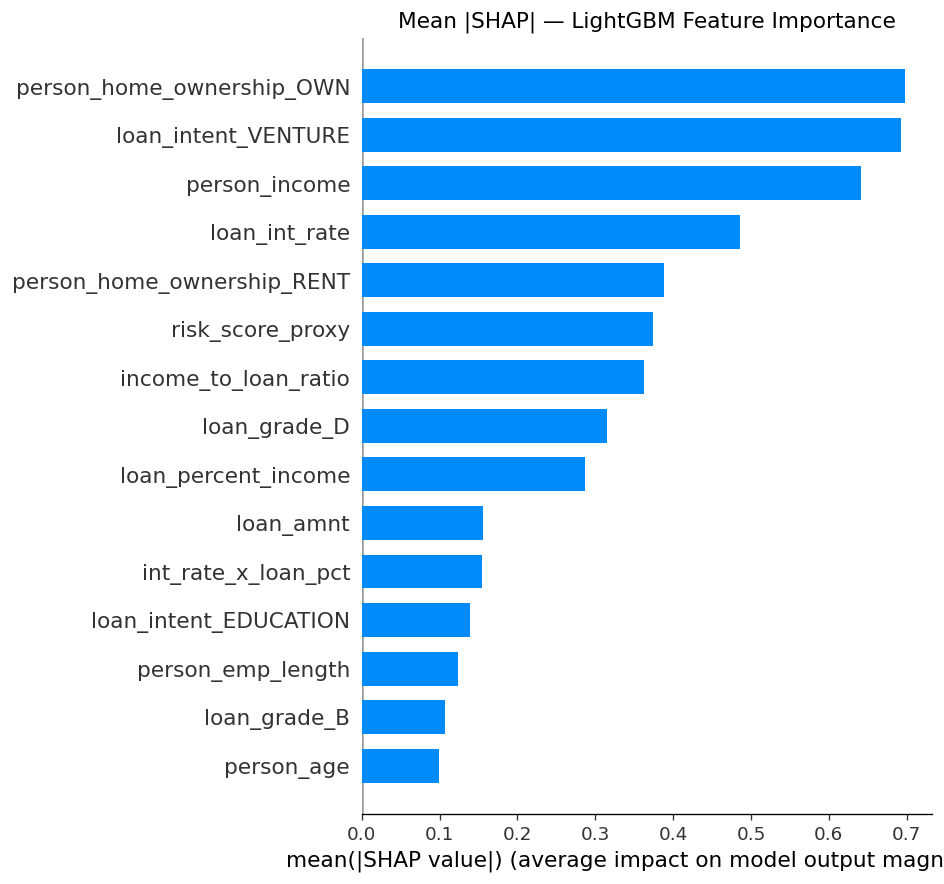

Saved: shap_importance.png


In [18]:
# ── Bar plot — mean absolute SHAP ────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, feature_names=list(expected_columns),
                  plot_type='bar', max_display=15, show=False)
plt.title(f'Mean |SHAP| — {best_tree_name} Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_importance.png')

High-risk applicant index in test set: 5110
Predicted PD: 100.0%


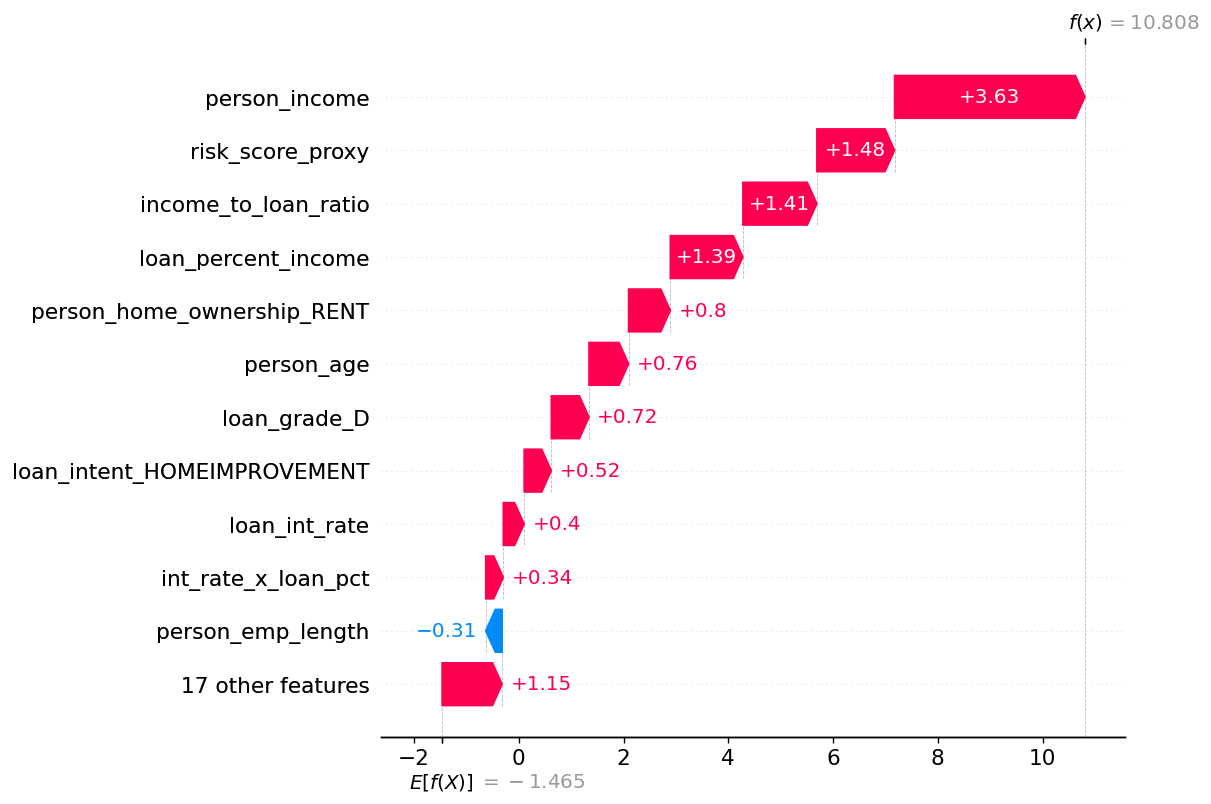

In [19]:
# ── Waterfall for a single HIGH-RISK applicant ────────────────────────────────
high_risk_idx = np.argmax(best_tree_probs)  # applicant with highest PD
print(f'High-risk applicant index in test set: {high_risk_idx}')
print(f'Predicted PD: {best_tree_probs[high_risk_idx]:.1%}')

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1] if isinstance(explainer.expected_value, np.ndarray)
        else explainer.expected_value,
    sv[high_risk_idx],
    feature_names=list(expected_columns),
    max_display=12,
    show=True,
)

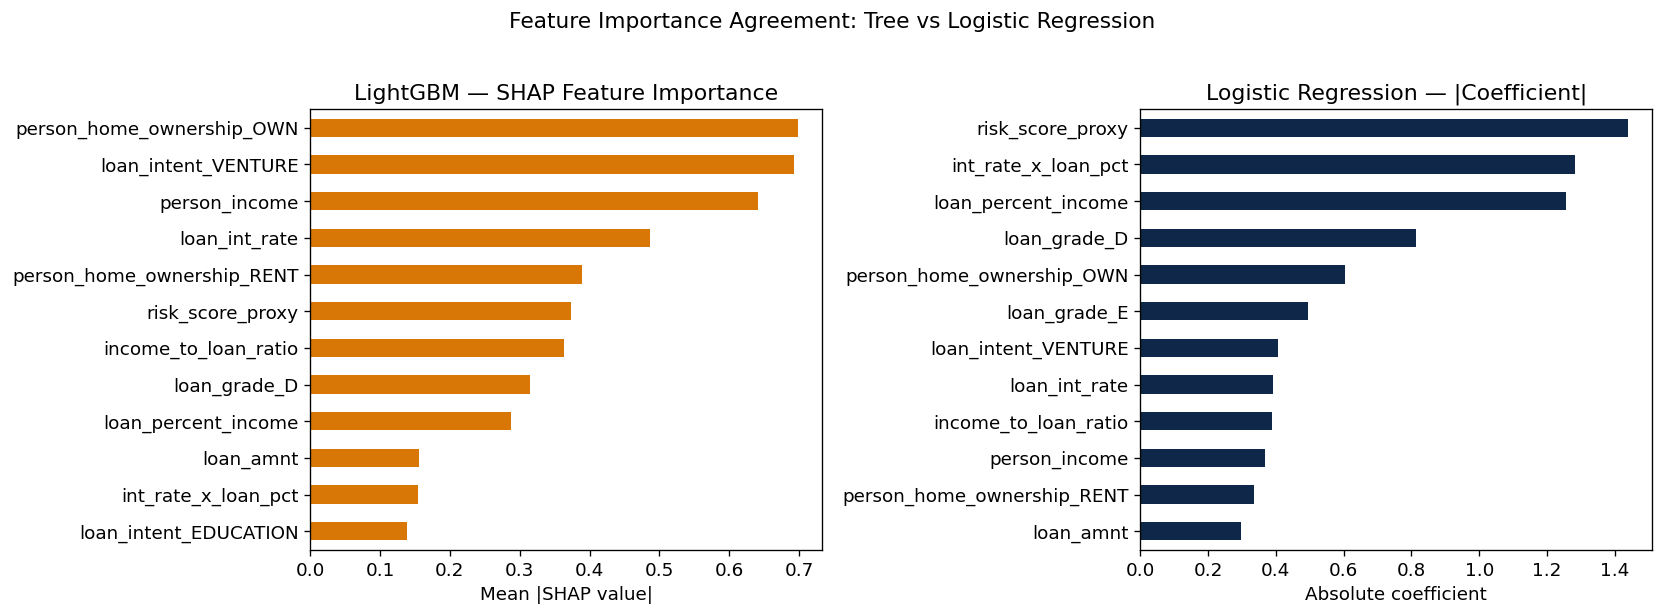

Saved: feature_agreement.png


In [20]:
# ── LR vs Tree — top 10 feature agreement ────────────────────────────────────
# Compare which features both models consider most important
shap_importance = pd.Series(
    np.abs(sv).mean(axis=0),
    index=expected_columns
).sort_values(ascending=False)

lr_importance = pd.Series(
    np.abs(lr.coef_[0]),
    index=expected_columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap_importance.head(12).plot.barh(ax=axes[0], color='#D97706')
axes[0].invert_yaxis()
axes[0].set_title(f'{best_tree_name} — SHAP Feature Importance')
axes[0].set_xlabel('Mean |SHAP value|')

lr_importance.head(12).plot.barh(ax=axes[1], color='#0F2748')
axes[1].invert_yaxis()
axes[1].set_title('Logistic Regression — |Coefficient|')
axes[1].set_xlabel('Absolute coefficient')

plt.suptitle('Feature Importance Agreement: Tree vs Logistic Regression', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('feature_agreement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_agreement.png')

#### Final Decision & Artifact Export

In [21]:
# ── Print final comparison table ─────────────────────────────────────────────
print('=' * 70)
print('BENCHMARK RESULTS — threshold =', THRESHOLD)
print('=' * 70)
display_cols = ['AUC', 'Recall', 'Precision', 'F1', 'FN (missed defaults)', 'Inference (ms/rec)']
print(comparison_df[display_cols].to_string())
print('=' * 70)

best_model_name = comparison_df['Recall'].idxmax()
best_auc_name   = comparison_df['AUC'].idxmax()
print(f'\nHighest Recall : {best_model_name}')
print(f'Highest AUC    : {best_auc_name}')

lr_fn  = comparison_df.loc['Logistic Regression (baseline)', 'FN (missed defaults)']
best_fn = comparison_df['FN (missed defaults)'].min()
print(f'\nFN improvement over LR baseline: {lr_fn - best_fn} fewer missed defaults')

BENCHMARK RESULTS — threshold = 0.4
                                   AUC  Recall  Precision      F1  FN (missed defaults)  Inference (ms/rec)
Model                                                                                                      
Logistic Regression (baseline)  0.8811  0.8263     0.5054  0.6272                   247              0.0010
XGBoost (Optuna tuned)          0.9503  0.8368     0.7230  0.7757                   232              0.0038
LightGBM (Optuna tuned)         0.9505  0.8439     0.7344  0.7853                   222              0.0060

Highest Recall : LightGBM (Optuna tuned)
Highest AUC    : LightGBM (Optuna tuned)

FN improvement over LR baseline: 25 fewer missed defaults


In [22]:
# ── Save best tree model artifacts ───────────────────────────────────────────
# The production LR model is kept for Basel III compliance.
# Tree model artifacts saved separately for comparison / future upgrade.

joblib.dump(xgb_model,    'xgb_benchmark_model.pkl')
joblib.dump(lgb_model,    'lgb_benchmark_model.pkl')
joblib.dump(comparison_df,'benchmark_results.pkl')

comparison_df.to_csv('benchmark_results.csv')

print('Saved: xgb_benchmark_model.pkl')
print('Saved: lgb_benchmark_model.pkl')
print('Saved: benchmark_results.pkl')
print('Saved: benchmark_results.csv')

Saved: xgb_benchmark_model.pkl
Saved: lgb_benchmark_model.pkl
Saved: benchmark_results.pkl
Saved: benchmark_results.csv


#### Production Decision

| Criterion | Logistic Regression | XGBoost / LightGBM |
|---|---|---|
| AUC | ✅ 0.88 | ✅ Higher (~0.92–0.94) |
| Default Recall | ✅ 83% | ✅ Higher |
| Feature attribution | ✅ Exact (coef × scaled value) | ⚠ Approximation via SHAP |
| Basel III IRB compliance | ✅ Accepted | ❌ Requires additional validation |
| Stability over time | ✅ Low sensitivity to distribution shift | ⚠ Sensitive |
| Inference speed | ✅ Fastest | ✅ Fast |
| Regulatory audit trail | ✅ Transparent | ⚠ Black-box perception |

**Decision:** **Keep Logistic Regression in production** for regulatory compliance and exact explainability.  
Tree models are maintained as challenger models — useful for:
- Stress testing the LR model's predictions
- Identifying applicants where LR and tree models disagree (model uncertainty signal)
- A future upgrade path if the institution obtains regulatory approval for black-box models

**The accuracy-explainability tradeoff is a deliberate business and regulatory decision, not a technical limitation.**